In [64]:
import numpy as np
from scipy.io.wavfile import read
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from IPython.display import Audio, display

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import soundfile as sf

### Preprocessing data

* Last 20% of data is validation
* Loss: signal to error ratio

In [65]:
class AudioAmpDataset(Dataset):
    def __init__(self, clean_path, target_path ,seq_len=512, calculate_norm=True):
        """
        Args:
            clean_path: Path to the input (DI) audio file.
            target_path: Path to the target (Distorted) audio file.
            seq_len: The number of samples per chunk.
        """

        self.clean_path = clean_path
        self.target_path = target_path
        self.seq_len = seq_len


        clean_info = sf.info(clean_path)
        target_info = sf.info(target_path)


        assert clean_info.frames == target_info.frames, "Clean and Target files must be the same length."

        self.total_frames = clean_info.frames

        self.clean_max = 1.0
        self.target_max = 1.0
        if calculate_norm:
            print("Calculating global maximums for normalization (this might take a few seconds)...")
            self._compute_global_max()

        # Calculate how many valid chunks
        self.num_chunks = self.total_frames // self.seq_len

    def __len__(self):
        return self.num_chunks

    def _compute_global_max(self, block_size=44100*5):

        current_Train_max = 0.0
        current_Valid_max = 0.0
        total_block = self.total_frames // block_size + 1

        for block_i in range(total_block):
            start_frame = block_i * block_size
            frames_to_read = min(block_size, self.total_frames - start_frame)
            Train_block, _ = sf.read(self.clean_path, frames=frames_to_read, start=start_frame, dtype='float32')
            Valid_block, _ = sf.read(self.target_path, frames=frames_to_read, start=start_frame, dtype='float32')
            Block_Train_max =  np.max(np.abs(Train_block))
            Block_Valid_max =  np.max(np.abs(Valid_block))

            if Block_Train_max > current_Train_max:
                current_Train_max = Block_Train_max
            if Block_Valid_max > current_Valid_max:
                current_Valid_max = Block_Valid_max

        self.clean_max = max(current_Train_max, 1e-8)
        self.target_max = max(current_Valid_max, 1e-8)
        print(f"Global Clean Max: {self.clean_max:.4f} | Global Target Max: {self.target_max:.4f}")

        return 1.0


    def __getitem__(self, idx):
        """
        This is where 'lazy loading' happens.
        It is only called when the DataLoader requests batch 'idx'.
        """

        start_frame = idx * self.seq_len

        # Read exactly 'seq_len' frames from disk
        clean_chunk, _ = sf.read(self.clean_path, frames=self.seq_len, start=start_frame, dtype='float32')
        target_chunk, _ = sf.read(self.target_path, frames=self.seq_len, start=start_frame, dtype='float32')

        # If stereo, convert to mono. soundfile returns shape (frames, channels)
        if clean_chunk.ndim > 1:
            clean_chunk = clean_chunk.mean(axis=1)
        if target_chunk.ndim > 1:
            target_chunk = target_chunk.mean(axis=1)


        clean_chunk = clean_chunk / self.clean_max
        target_chunk = target_chunk / self.target_max
        # Reshape to expected (Sequence, Features) which is (512, 1)
        clean_tensor = torch.tensor(clean_chunk, dtype=torch.float32).unsqueeze(-1)
        target_tensor = torch.tensor(target_chunk, dtype=torch.float32).unsqueeze(-1)

        return clean_tensor, target_tensor

In [83]:
dataset = AudioAmpDataset(
    clean_path="Data/ML_Guitar_Initial_Data.wav",
    target_path="Data/ML_Guitar_Target_Data.wav",
    seq_len=1024
)
train_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,       # Shuffle the chunks for better training
    num_workers=0,      # Uses 2 background processes to read from disk concurrently
    pin_memory=True    # Speeds up transferring data to MPS/GPU
)

Calculating global maximums for normalization (this might take a few seconds)...
Global Clean Max: 0.9990 | Global Target Max: 0.5515


### Creating model

In [93]:
class Net(nn.Module):
    def __init__(self, input_size = 1, hidden_size=128):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.linear = nn.Linear(hidden_size, out_features=input_size)
        
    def forward(self, x):
        residual, _ = self.lstm(x)  # Run LSTM and store the hidden layer outputs
        residual = self.linear(residual) # a normal dense layer
        x += residual
        return x

In [94]:
net = Net()
opt = torch.optim.Adam(net.parameters(), lr=5e-3)
progress_bar = tqdm(range(1))
loss_arr = []
for epoch in progress_bar:
    epoch_loss = 0
    for batch_idx, (clean_batch, target_batch) in enumerate(train_loader):
        opt.zero_grad()
        
        # Move the small batch to device
        clean_batch = clean_batch.to("cpu")
        target_batch = target_batch.to("cpu")

        prediction = net(clean_batch)
        loss = nn.MSELoss()(prediction, target_batch)
        # loss = torch.sum((prediction.flatten() - target_batch.flatten())**2/target_batch.flatten()**2)
        loss.backward()
        opt.step()

        epoch_loss += loss.item()
    
    progress_bar.set_description(f'Loss = {float(epoch_loss):6.4f}')
    loss_arr.append(float(epoch_loss))


  0%|          | 0/1 [00:00<?, ?it/s]c:\Users\Bruger\anaconda3\envs\MachineLearning\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Loss = 1.6467: 100%|██████████| 1/1 [00:55<00:00, 55.14s/it]


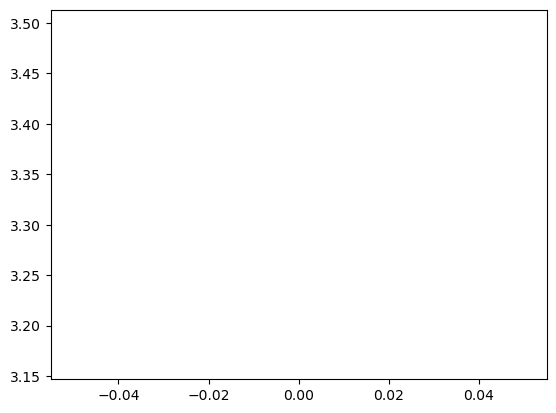

In [82]:
plt.plot(loss_arr)